# 한국 관광 출입국통계 수집

한국관광공사 **출입국관광통계** API에서 월별 국적별 입국자수를 수집합니다.

- 엔드포인트: `http://openapi.tour.go.kr/openapi/service/EdrcntTourismStatsService/getEdrcntTourismStatsList`
- 저장: `<OneDrive>/INVESTMENT/지표상회_복제/tourism/korea_visiting_num_{날짜}.csv`

## 기존 `korea_tourism_stats.py` 에서 바뀐 점

| 항목 | 기존 | 변경 |
|---|---|---|
| 호출 횟수 | 국가 수 × 개월 수 | **개월 수만** (아래 설명) |
| `_parse_header()` | `find_text()` — 존재하지 않는 메서드 | 제거 |
| XML 파서 | BeautifulSoup + lxml | `xml.etree` (표준 라이브러리) |
| 에러 응답 | `resultCode` 만 확인 | 인증 실패 XML 봉투까지 처리 |
| 컬럼명 | `인원` (노트북은 `입국자수` 를 찾아 차트가 빈 채로 나왔음) | 통일 |
| 저장 | 없음 | 경로 자동 탐색 + CSV |

### 호출 횟수를 줄인 이유
`NAT_CD` 를 빼고 요청하면 **그 달의 전 국적이 한 번에** 옵니다.
기존 코드는 '전체'를 그렇게 받아놓고 일본·중국을 또 따로 요청했는데,
이미 받은 응답 안에 두 나라가 들어 있습니다. 15년치 기준 540회 → 180회로 줄었습니다.

## 0. 패키지 설치 (최초 1회만)

In [1]:
# !pip install requests pandas matplotlib
import sys
print(sys.version)

3.9.10 (tags/v3.9.10:f2f3f53, Jan 17 2022, 15:14:21) [MSC v.1929 64 bit (AMD64)]


## 1. 설정

`ED_CODE` 는 방향을 정합니다.

- `E` : 방한 외래관광객 (입국) ← 기본값
- `D` : 국민 해외관광객 (출국)

In [2]:
# -*- coding: utf-8 -*-
import os

# ============================================================
# 사용자 설정
# ============================================================

# 공공데이터포털 Decoding 키
SERVICE_KEY = "2o6NG3ixxDgGQ9S4dWUgsMac9WlxfX46+JvFRsAlsXQ6xVi6CZewvNJvbHd4S7exkWwt3YWoKSdwvUNb46kSTQ=="

# 수집 방향  E=방한외래관광객(입국) / D=국민해외관광객(출국)
ED_CODE = "E"

# 수집 기간
YEARS_BACK = 15           # 최근 N년
BEGIN_YM = None           # 직접 지정하려면 "201001" 형태. None 이면 YEARS_BACK 사용
END_YM   = None           # None 이면 지난달까지

# 와이드 CSV 의 앞쪽 컬럼 순서. 전 국적은 어차피 다 수집됩니다.
FOCUS_COUNTRIES = ["중국", "일본", "대만", "미국", "홍콩"]

# 차트에 표시할 상위 N개국 (최근 12개월 누적 기준 자동 선정)
TOP_N_CHART = 5

# 이동평균 개월 수 (계절성 제거용)
SMOOTH_MONTHS = 12

# 동시 요청 수. 관광공사 API 는 과하면 실패가 늘어나므로 5 정도가 무난
MAX_WORKERS = 5
RETRIES = 2
TIMEOUT = 20

# ------------------------------------------------------------
# 저장 설정   ※ 실제 경로는 다음 셀에서 자동 탐색
# ------------------------------------------------------------
OUT_DIR_OVERRIDE = None
# 예) OUT_DIR_OVERRIDE = r"C:\Users\82108\OneDrive\INVESTMENT\지표상회_복제\tourism"

ONEDRIVE_SUBPATH = ("INVESTMENT", "지표상회_복제", "tourism")

# 이름 검색 폴백에 쓸 앵커. 'tourism' 은 흔한 이름이라 상위의 고유 폴더를 기준으로 찾습니다.
ANCHOR_FOLDER = "지표상회_복제"
LEAF_FOLDER   = "tourism"

FILE_PREFIX = "korea_visiting_num"

# 파일명 날짜: "lastdata" = 데이터 최종 월(YYYYMM), "today" = 실행일(YYYYMMDD)
DATE_TAG_MODE = "lastdata"

OVERWRITE = True
SAVE_LONG = True          # 전 국적 원본(long) CSV 도 저장할지

# ============================================================
BASE_URL = ("http://openapi.tour.go.kr/openapi/service/"
            "EdrcntTourismStatsService/getEdrcntTourismStatsList")

print("설정 완료 | 방향:", "방한 외래객(E)" if ED_CODE == "E" else "국민 해외여행(D)")

설정 완료 | 방향: 방한 외래객(E)


## 2. 저장 경로 자동 탐색

데스크탑과 노트북의 경로가 달라도 찾아냅니다.

1. `OUT_DIR_OVERRIDE` 가 있으면 그것을 사용
2. 환경변수 `OneDrive` / `OneDriveConsumer` / `OneDriveCommercial` + 상대경로
3. 홈 디렉터리의 `OneDrive*` 폴더 (`OneDrive - 회사명` 포함) + 상대경로
4. 상위 폴더가 있으면 `tourism` 을 새로 생성
5. **`지표상회_복제` 폴더를 이름으로 검색**한 뒤 그 아래 `tourism` 생성
6. 전부 실패하면 `./data/tourism` 으로 폴백

5번에서 `tourism` 이 아니라 상위의 `지표상회_복제` 를 찾는 이유는,
`tourism` 은 흔한 폴더명이라 엉뚱한 곳이 잡힐 수 있기 때문입니다.

In [3]:
# -*- coding: utf-8 -*-
import os
import glob


def _dedup(seq):
    seen, out = set(), []
    for x in seq:
        if x and x not in seen:
            seen.add(x)
            out.append(x)
    return out


def find_onedrive_roots():
    roots = []
    for var in ("OneDrive", "OneDriveConsumer", "OneDriveCommercial"):
        roots.append(os.environ.get(var))

    home = os.path.expanduser("~")
    for pat in ("OneDrive", "OneDrive*", "OneDrive - *"):
        for hit in glob.glob(os.path.join(home, pat)):
            if os.path.isdir(hit):
                roots.append(hit)

    for drive in ("C:", "D:", "E:"):
        cand = os.path.join(drive + os.sep, "OneDrive")
        if os.path.isdir(cand):
            roots.append(cand)

    return _dedup([os.path.normpath(r) for r in roots if r and os.path.isdir(r)])


def search_folder_by_name(roots, name, max_depth=5):
    for root in roots:
        base_depth = root.rstrip(os.sep).count(os.sep)
        for dirpath, dirnames, _ in os.walk(root):
            if dirpath.count(os.sep) - base_depth >= max_depth:
                dirnames[:] = []
                continue
            dirnames[:] = [d for d in dirnames
                           if not d.startswith(".") and not d.startswith("~$")]
            if name in dirnames:
                return os.path.join(dirpath, name)
    return None


def resolve_out_dir(verbose=True):
    sub = os.path.join(*ONEDRIVE_SUBPATH)

    if OUT_DIR_OVERRIDE:
        path = os.path.normpath(os.path.expanduser(OUT_DIR_OVERRIDE))
        os.makedirs(path, exist_ok=True)
        if verbose:
            print("[1] OUT_DIR_OVERRIDE 사용")
        return path

    roots = find_onedrive_roots()
    if verbose:
        print("탐지된 OneDrive 루트:")
        for r in roots:
            print("   -", r)
        if not roots:
            print("   (없음)")
        print()

    candidates = [os.path.join(r, sub) for r in roots]

    for c in candidates:
        if os.path.isdir(c):
            if verbose:
                print("[2] 기존 폴더 발견")
            return c

    for c in candidates:
        if os.path.isdir(os.path.dirname(c)):
            os.makedirs(c, exist_ok=True)
            if verbose:
                print("[4] 상위 폴더 확인 후 tourism 생성")
            return c

    if roots:
        if verbose:
            print("[5] '{}' 를 이름으로 검색 중...".format(ANCHOR_FOLDER))
        anchor = search_folder_by_name(roots, ANCHOR_FOLDER)
        if anchor:
            path = os.path.join(anchor, LEAF_FOLDER)
            os.makedirs(path, exist_ok=True)
            if verbose:
                print("[5] 앵커 발견 →", anchor)
            return path

    fallback = os.path.abspath(os.path.join("./data", LEAF_FOLDER))
    os.makedirs(fallback, exist_ok=True)
    if verbose:
        print("[6] !! OneDrive 경로를 찾지 못해 로컬 폴더로 폴백합니다.")
        print("     OUT_DIR_OVERRIDE 에 경로를 직접 넣어주세요.")
    return fallback


OUT_DIR = resolve_out_dir()

print()
print("최종 저장 경로 :", OUT_DIR)
print("쓰기 가능 여부 :", os.access(OUT_DIR, os.W_OK))

탐지된 OneDrive 루트:
   - C:\Users\82108\OneDrive

[2] 기존 폴더 발견

최종 저장 경로 : C:\Users\82108\OneDrive\INVESTMENT\지표상회_복제\tourism
쓰기 가능 여부 : True


## 3. 수집 함수

응답 필드는 `ym`(년월), `natCd`(국가코드), `natKorNm`(국적명), `num`(인원),
`ed`/`edCd`(구분) 입니다.

인증 실패나 트래픽 초과는 `<OpenAPI_ServiceResponse>` 봉투로 오기 때문에
`resultCode` 만 보면 놓칩니다. 두 형태를 모두 처리합니다.

In [4]:
# -*- coding: utf-8 -*-
import time
import xml.etree.ElementTree as ET
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import datetime
from dateutil.relativedelta import relativedelta

import requests
import pandas as pd


OK_CODES = {"0000", "00", "0", ""}


class TourismApiError(Exception):
    pass


def build_month_list(years_back=15, begin_ym=None, end_ym=None):
    """YYYYMM 문자열 리스트 생성. 기본은 최근 N년 ~ 지난달"""
    end = (datetime.strptime(end_ym, "%Y%m") if end_ym
           else datetime.now() - relativedelta(months=1))
    start = (datetime.strptime(begin_ym, "%Y%m") if begin_ym
             else end - relativedelta(years=years_back))

    out, cur = [], start.replace(day=1)
    while cur <= end:
        out.append(cur.strftime("%Y%m"))
        cur += relativedelta(months=1)
    return out


def _parse(text):
    """XML 응답 → item 딕셔너리 리스트"""
    root = ET.fromstring(text)

    # 인증/트래픽 오류 봉투
    if root.tag.endswith("OpenAPI_ServiceResponse"):
        code = root.findtext(".//returnReasonCode") or "?"
        msg = (root.findtext(".//returnAuthMsg")
               or root.findtext(".//errMsg") or "")
        raise TourismApiError("[{}] {}".format(code, msg))

    rc = (root.findtext(".//resultCode") or "").strip()
    if rc not in OK_CODES:
        msg = (root.findtext(".//resultMsg") or "").strip()
        raise TourismApiError("[{}] {}".format(rc, msg))

    rows = []
    for item in root.iter("item"):
        rows.append({ch.tag: (ch.text or "").strip() for ch in item})
    return rows


def fetch_month(ym, ed_code=None, nat_cd=None, retries=None, timeout=None):
    """단일 월 조회. nat_cd 를 주지 않으면 그 달의 전 국적이 한 번에 온다."""
    ed_code = ed_code or ED_CODE
    retries = RETRIES if retries is None else retries
    timeout = TIMEOUT if timeout is None else timeout

    params = {"serviceKey": SERVICE_KEY, "YM": ym, "ED_CD": ed_code,
              "numOfRows": 1000, "pageNo": 1}
    if nat_cd:
        params["NAT_CD"] = str(nat_cd)

    last = None
    for attempt in range(retries + 1):
        try:
            r = requests.get(BASE_URL, params=params, timeout=timeout)
            r.raise_for_status()
            return _parse(r.text), None
        except TourismApiError as e:
            return [], str(e)          # API 레벨 오류는 재시도해도 동일
        except Exception as e:
            last = e
            if attempt < retries:
                time.sleep(0.4 * (attempt + 1))
    return [], "{}: {}".format(type(last).__name__, last)


def fetch_bulk(month_list, ed_code=None, max_workers=None, verbose=True):
    """여러 달을 병렬 수집. 실패한 달 목록도 함께 반환."""
    max_workers = max_workers or MAX_WORKERS
    rows, failed = [], []

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futs = {ex.submit(fetch_month, ym, ed_code): ym for ym in month_list}
        done = 0
        for fut in as_completed(futs):
            ym = futs[fut]
            try:
                data, err = fut.result()
            except Exception as e:
                data, err = [], str(e)

            if err:
                failed.append((ym, err))
            else:
                rows.extend(data)

            done += 1
            if verbose and done % 24 == 0:
                print("   진행 {:>3}/{:<3}  누적 {:,}행".format(
                    done, len(month_list), len(rows)))

    if verbose:
        print("\n수집 완료: {:,}행 / 실패 {}개월".format(len(rows), len(failed)))
        for ym, err in failed[:5]:
            print("   실패 {} → {}".format(ym, err))
        if len(failed) > 5:
            print("   ... 외 {}개월".format(len(failed) - 5))

    return pd.DataFrame(rows), failed


print("수집 함수 로드 완료")

수집 함수 로드 완료


## 4. 연결 테스트

한 달치만 받아서 인증키와 응답 구조를 확인합니다.

In [5]:
months = build_month_list(YEARS_BACK, BEGIN_YM, END_YM)
print("수집 기간: {} ~ {}  ({}개월)".format(months[0], months[-1], len(months)))

rows, err = fetch_month(months[-1])
if err:
    print("\n!! 실패:", err)
else:
    print("\n{} : {}개 국적".format(months[-1], len(rows)))
    print("\n필드 구조:")
    for k, v in (rows[0] if rows else {}).items():
        print("   {:<12} {}".format(k, v))
    print("\n상위 5개:")
    for r in sorted(rows, key=lambda x: -int(x.get("num", 0) or 0))[:5]:
        print("   {:<16} {:>12,}".format(r.get("natKorNm", ""),
                                         int(r.get("num", 0) or 0)))

수집 기간: 201106 ~ 202606  (181개월)

202606 : 200개 국적

필드 구조:
   ed           방한외래관광객
   edCd         E
   natCd        105
   natKorNm     방글라데시
   num          2891
   rnum         1
   ym           202606

상위 5개:
   중  국                  649,582
   일  본                  348,216
   대  만                  223,127
   미  국                  177,744
   홍  콩                   65,690


## 5. 국적 목록 진단 (중요)

전 국적을 합산해 '전체'를 만들 때, 응답에 **대륙 소계나 합계 행이 섞여 있으면
이중 계산**이 됩니다. 기존 코드는 이 확인 없이 그냥 `sum()` 을 했습니다.

아래에서 국적명을 전부 출력하고, 소계로 의심되는 항목을 표시합니다.
의심 항목이 있으면 `EXCLUDE_NAMES` 에 넣으세요.

In [6]:
SUSPECT = ("계", "합계", "소계", "총계", "전체", "주", "기타")

if not err and rows:
    names = sorted({r.get("natKorNm", "") for r in rows})
    print("국적 수:", len(names))
    print()
    flagged = [n for n in names if any(s in n for s in SUSPECT)]
    for n in names:
        mark = "  ← 확인 필요" if n in flagged else ""
        print("   {}{}".format(n, mark))
    print()
    if flagged:
        print("!! 소계 의심 항목 {}개: {}".format(len(flagged), flagged))
        print("   실제 소계라면 아래 EXCLUDE_NAMES 에 넣으세요.")
    else:
        print("소계로 보이는 항목 없음 → 단순 합산해도 안전합니다.")

# 합산에서 제외할 국적명 (위 진단 결과를 보고 채우세요)
EXCLUDE_NAMES = []

국적 수: 200

   가  나
   가  봉
   가이아나
   감비아
   과테말라
   교포
   국제연합
   그레나다
   그루지아
   그리스
   기  니
   기니비사우
   나미비아
   나우루
   나이지리아
   남수단공화국
   남아프리카 공화국
   네  팔
   네덜란드
   노르웨이
   뉴질랜드
   니제르
   니카라과
   대  만
   덴마크
   도미니카공화국
   도미니카연방
   독  일
   라오스
   라이베리아
   라트비아
   러시아(연방)
   레바논
   레소토
   루마니아
   룩셈부르크
   르완다
   리비아
   리투아니아
   리히텐슈타인
   마다가스카르
   마샬군도
   마카오
   마케도니아
   말  리
   말라위
   말레이시아
   멕시코
   모나코
   모로코
   모리셔스
   모리타니
   모잠비크
   몬테네그로
   몰  타
   몰도바
   몰디브
   몽  골
   미  국
   미상
   미얀마
   미크로네시아
   바레인
   바베이도스
   바하마
   방글라데시
   베  냉
   베네수엘라
   베트남
   벨기에
   벨로루시
   벨리즈
   보스니아-헤르체고비나
   보츠와나
   볼리비아
   부  탄
   부룬디
   부르키나파소
   불가리아
   브라질
   브루나이
   비누아투
   사모아
   사우디아라비아
   산마리노
   세네갈
   세르비아
   세이셸
   세인트루시아
   세인트빈센트 그레나딘
   세인트크리스토퍼 네비스
   소말리아
   솔로몬군도
   수  단
   수리남
   스리랑카
   스와질란드
   스웨덴
   스위스
   스페인
   슬로바크
   슬로베니아
   시리아
   시에라리온
   싱가포르
   아랍에미리트연합
   아르메니아
   아르헨티나
   아이슬란드
   아이티
   아일랜드
   아제르바이잔
   아프가니스탄
   안도라
   알바니아
   알제리
   앙골라
   앤티가 바부다
   에리트레

## 6. 전체 기간 수집

In [7]:
raw, failed = fetch_bulk(months)
print("\nshape:", raw.shape)
raw.head()

   진행  24/181  누적 4,916행
   진행  48/181  누적 9,739행
   진행  72/181  누적 14,550행
   진행  96/181  누적 19,374행
   진행 120/181  누적 24,063행
   진행 144/181  누적 28,571행
   진행 168/181  누적 33,385행

수집 완료: 35,986행 / 실패 0개월

shape: (35986, 7)


,ed,edCd,natCd,natKorNm,num,rnum,ym
0,방한외래관광객,E,105,방글라데시,727,1,201109
1,방한외래관광객,E,108,미얀마,5922,2,201109
2,방한외래관광객,E,111,스리랑카,1522,3,201109
3,방한외래관광객,E,112,중 국,231462,4,201109
4,방한외래관광객,E,113,대 만,37205,5,201109


## 7. 정리 및 피벗

- `날짜` : 해당 월의 말일 (`2026-06-30` 형태)
- `국적` / `국가코드` / `인원`
- `전체` : 소계 제외 후 월별 합계

와이드 표는 `FOCUS_COUNTRIES` 를 앞쪽에, 나머지는 최근 12개월 합계가 큰 순서로 둡니다.

In [8]:
RENAME = {"ym": "년월", "natCd": "국가코드", "natKorNm": "국적",
          "num": "인원", "ed": "구분", "edCd": "구분코드"}

df = raw.rename(columns=RENAME).copy()

# ── 국적명 정규화 (중요)
# API 가 2글자 국가명에 자릿수 맞춤용 공백을 넣어 보냅니다: "중  국", "일  본"
# 그대로 두면 컬럼명이 지저분하고 다른 데이터와 조인할 때 계속 어긋납니다.
_before = df["국적"].astype(str)
df["국적"] = _before.str.replace(r"\s+", "", regex=True).str.strip()
_fixed = sorted({(a, b) for a, b in zip(_before, df["국적"]) if a != b})
if _fixed:
    print("국적명 공백 제거 {}건:".format(len(_fixed)))
    for a, b in _fixed[:12]:
        print("   {!r} → {!r}".format(a, b))
    if len(_fixed) > 12:
        print("   ... 외 {}건".format(len(_fixed) - 12))
    print()

df["인원"] = pd.to_numeric(df["인원"], errors="coerce")
df["날짜"] = (pd.to_datetime(df["년월"], format="%Y%m", errors="coerce")
              + pd.offsets.MonthEnd(0))
df = df.dropna(subset=["날짜", "국적"])

if EXCLUDE_NAMES:
    before = len(df)
    df = df[~df["국적"].isin(EXCLUDE_NAMES)]
    print("소계 제외: {}행 → {}행".format(before, len(df)))

# 같은 (날짜, 국적) 중복 방어
df = (df.groupby(["날짜", "국적", "국가코드"], as_index=False)["인원"]
        .sum(min_count=1))

# ── 와이드 피벗
wide = df.pivot_table(index="날짜", columns="국적", values="인원",
                      aggfunc="sum")
wide["전체"] = wide.sum(axis=1)

# 컬럼 순서: 전체 → 관심국가 → 나머지(최근 12개월 규모순)
recent = wide.tail(12).sum().drop("전체", errors="ignore")
rest = [c for c in recent.sort_values(ascending=False).index
        if c not in FOCUS_COUNTRIES]
order = ["전체"] + [c for c in FOCUS_COUNTRIES if c in wide.columns] + rest
wide = wide[[c for c in order if c in wide.columns]]
wide.index.name = "날짜"

print("기간:", wide.index.min().date(), "~", wide.index.max().date())
print("월수:", len(wide), "| 국적 수:", wide.shape[1] - 1)
print()
_cols = ["전체"] + [c for c in FOCUS_COUNTRIES if c in wide.columns][:4]
print(wide[_cols].tail(6).to_string(
    float_format=lambda v: "{:,.0f}".format(v)))

국적명 공백 제거 54건:
   '가  나' → '가나'
   '가  봉' → '가봉'
   '기  니' → '기니'
   '남아프리카 공화국' → '남아프리카공화국'
   '남조지아 남샌드위치 군도' → '남조지아남샌드위치군도'
   '네  팔' → '네팔'
   '네덜란드령 앤틸리스' → '네덜란드령앤틸리스'
   '대  만' → '대만'
   '독  일' → '독일'
   '동  독' → '동독'
   '말  리' → '말리'
   '몰  타' → '몰타'
   ... 외 42건

기간: 2011-06-30 ~ 2026-06-30
월수: 181 | 국적 수: 232

국적                전체      중국      일본      대만      미국
날짜                                                  
2026-01-31 1,265,658 418,703 225,351 166,779  76,212
2026-02-28 1,431,472 504,563 232,835 183,753  80,540
2026-03-31 2,045,992 501,060 481,789 192,138 152,416
2026-04-30 2,027,860 574,283 304,053 192,854 173,457
2026-05-31 1,945,809 563,600 357,530 191,795 151,605
2026-06-30 1,993,128 649,582 348,216 223,127 177,744


## 8. 저장

`<OUT_DIR>/korea_visiting_num_{날짜}.csv`

- 인코딩 `utf-8-sig` — 엑셀에서 한글이 깨지지 않습니다
- `SAVE_LONG = True` 면 전 국적 long 포맷도 함께 저장합니다
- 파일이 열려 있으면 시각을 붙인 이름으로 우회 저장합니다

In [9]:
# -*- coding: utf-8 -*-
import os
from datetime import datetime


def make_date_tag():
    if DATE_TAG_MODE == "lastdata" and len(wide):
        return wide.index.max().strftime("%Y%m")
    return datetime.now().strftime("%Y%m%d")


def resolve_filename(out_dir, base, ext=".csv"):
    path = os.path.join(out_dir, base + ext)
    if OVERWRITE or not os.path.exists(path):
        return path
    i = 2
    while True:
        path = os.path.join(out_dir, "{}_v{}{}".format(base, i, ext))
        if not os.path.exists(path):
            return path
        i += 1


def safe_to_csv(df_, path, **kw):
    try:
        df_.to_csv(path, **kw)
        return path
    except PermissionError:
        root, ext = os.path.splitext(path)
        alt = "{}_{}{}".format(root, datetime.now().strftime("%H%M%S"), ext)
        print("!! 파일이 열려 있어 다른 이름으로 저장합니다.")
        df_.to_csv(alt, **kw)
        return alt


date_tag = make_date_tag()
base_name = "{}_{}".format(FILE_PREFIX, date_tag)

out = wide.copy()
out.index = out.index.strftime("%Y-%m-%d")

main_path = resolve_filename(OUT_DIR, base_name, ".csv")
saved = safe_to_csv(out, main_path, encoding="utf-8-sig")
print("저장 완료 :", saved)
print("           {}행 × {}열".format(len(out), out.shape[1]))

if SAVE_LONG:
    lng = df.copy()
    lng["날짜"] = lng["날짜"].dt.strftime("%Y-%m-%d")
    lng = lng[["날짜", "국적", "국가코드", "인원"]].sort_values(["날짜", "국적"])
    long_path = resolve_filename(OUT_DIR, base_name + "_long", ".csv")
    saved_long = safe_to_csv(lng, long_path, index=False, encoding="utf-8-sig")
    print("long 저장 :", saved_long)
    print("           {:,}행".format(len(lng)))

print("\n폴더 내 파일:")
for f in sorted(os.listdir(OUT_DIR)):
    print("   ", f)

저장 완료 : C:\Users\82108\OneDrive\INVESTMENT\지표상회_복제\tourism\korea_visiting_num_202606.csv
           181행 × 233열
long 저장 : C:\Users\82108\OneDrive\INVESTMENT\지표상회_복제\tourism\korea_visiting_num_202606_long.csv
           35,986행

폴더 내 파일:
    korea_visiting_num_202606.csv
    korea_visiting_num_202606_long.csv


## 9. 차트

최근 12개월 누적 기준 **상위 5개국을 자동 선정**해 그립니다.
`TOP_N_CHART` 만 바꾸면 개수가 달라집니다.

월별 원계열은 계절성 때문에 톱니처럼 보여서, 얇은 실선(원계열)과
굵은 실선(12개월 이동평균)을 겹쳐 그립니다.

세 번째 패널은 **비중(%)** 입니다. 중국·일본이 워낙 커서 절대값 차트로는
하위권 움직임이 안 보이는데, 비중으로 보면 국적 구성이 어떻게 바뀌는지 드러납니다.

차트 폰트: Malgun Gothic
상위 5개국: 중국(29.6%), 일본(19.1%), 대만(10.5%), 미국(7.5%), 홍콩(3.2%)


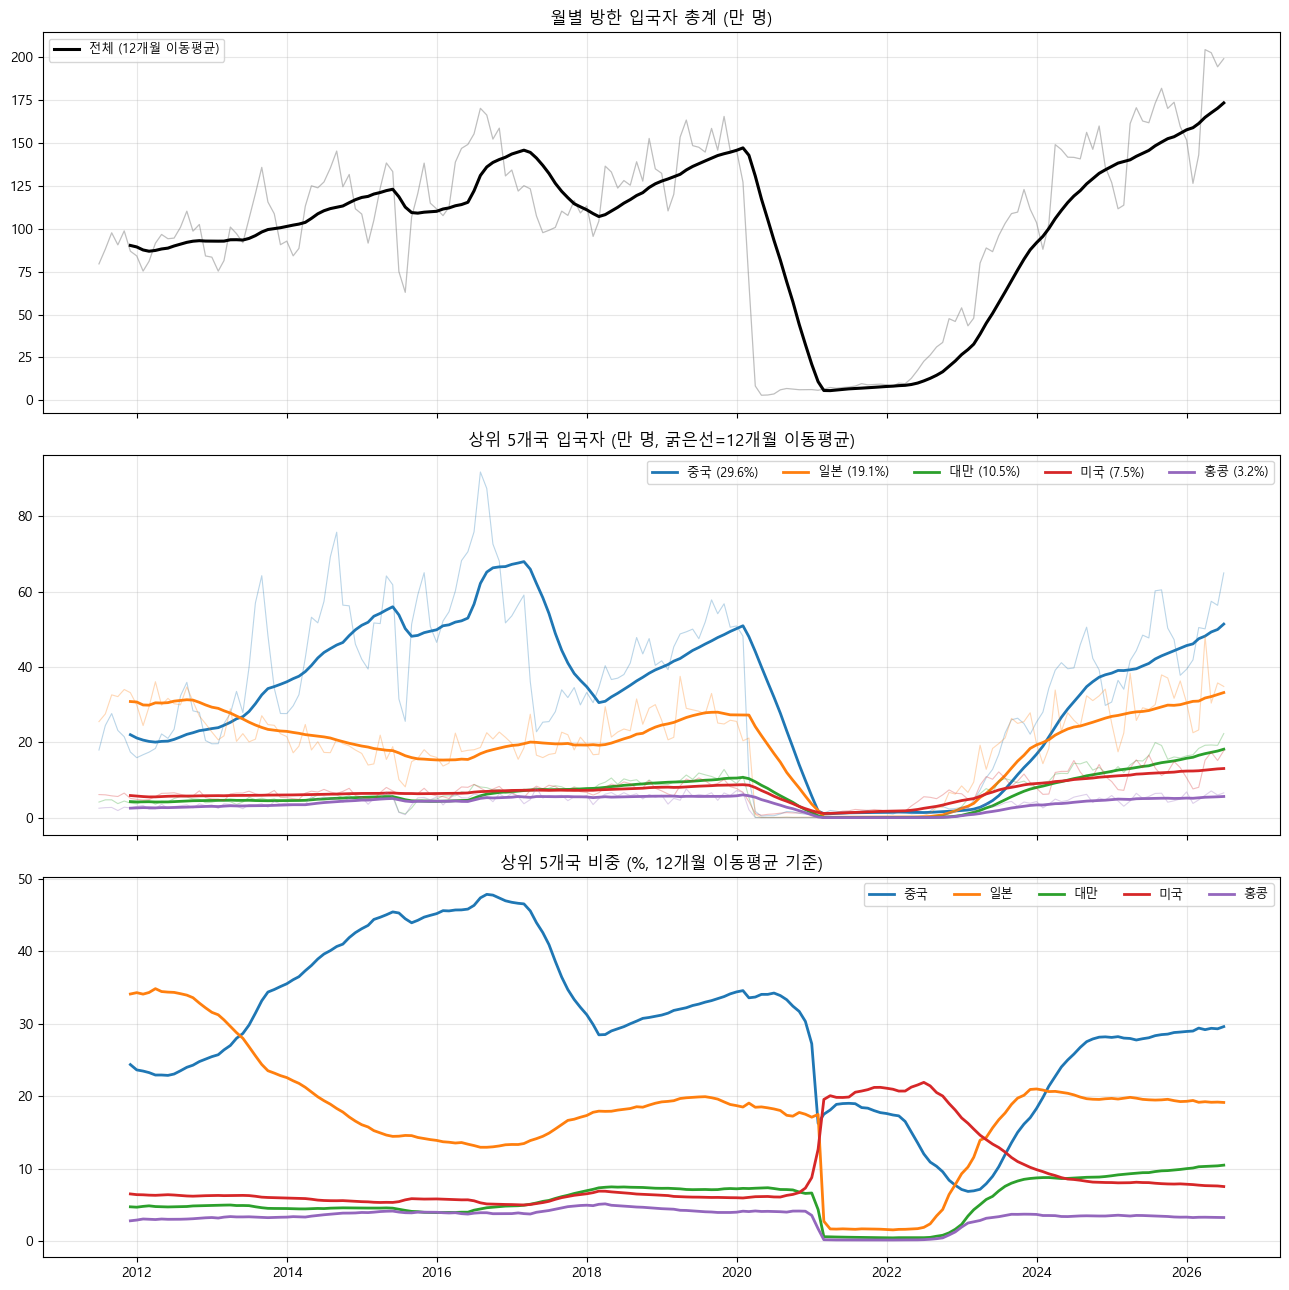

In [10]:
import matplotlib
import matplotlib.pyplot as plt
import platform
from matplotlib import font_manager


def set_korean_font():
    prefer = {
        "Windows": ["Malgun Gothic", "NanumGothic", "Gulim"],
        "Darwin":  ["AppleGothic", "Apple SD Gothic Neo", "NanumGothic"],
        "Linux":   ["NanumGothic", "NanumBarunGothic", "Noto Sans CJK KR"],
    }
    have = {f.name for f in font_manager.fontManager.ttflist}
    for name in prefer.get(platform.system(), []) + ["Malgun Gothic", "AppleGothic"]:
        if name in have:
            matplotlib.rcParams["font.family"] = name
            return name
    print("!! 한글 폰트를 찾지 못했습니다.")
    return None


print("차트 폰트:", set_korean_font())
matplotlib.rcParams["axes.unicode_minus"] = False

# ── 최근 12개월 누적 기준 상위 N개국 자동 선정
recent12 = wide.tail(12).sum().drop("전체", errors="ignore")
TOP = list(recent12.sort_values(ascending=False).head(TOP_N_CHART).index)
share = (recent12[TOP] / recent12.sum() * 100).round(1)
print("상위 {}개국: ".format(TOP_N_CHART)
      + ", ".join("{}({}%)".format(c, share[c]) for c in TOP))

MA = SMOOTH_MONTHS
_ma = lambda ser: ser.rolling(MA, min_periods=max(3, MA // 2)).mean()

fig, ax = plt.subplots(3, 1, figsize=(13, 13), sharex=True)

# (1) 전체
ax[0].plot(wide.index, wide["전체"] / 1e4, color="gray", lw=0.9, alpha=0.5)
ax[0].plot(wide.index, _ma(wide["전체"]) / 1e4, color="k", lw=2.2,
           label="전체 ({}개월 이동평균)".format(MA))
ax[0].set_title("월별 방한 입국자 총계 (만 명)" if ED_CODE == "E"
                else "월별 국민 해외관광객 총계 (만 명)")
ax[0].legend(fontsize=9)
ax[0].grid(alpha=0.3)

# (2) 상위 N개국 절대 인원
colors = plt.cm.tab10.colors
for i, c in enumerate(TOP):
    col = colors[i % len(colors)]
    ax[1].plot(wide.index, wide[c] / 1e4, color=col, lw=0.8, alpha=0.30)
    ax[1].plot(wide.index, _ma(wide[c]) / 1e4, color=col, lw=2.0,
               label="{} ({}%)".format(c, share[c]))
ax[1].set_title("상위 {}개국 입국자 (만 명, 굵은선={}개월 이동평균)".format(
    TOP_N_CHART, MA))
ax[1].legend(ncol=TOP_N_CHART, fontsize=9)
ax[1].grid(alpha=0.3)

# (3) 상위 N개국 비중
tot_ma = _ma(wide["전체"])
for i, c in enumerate(TOP):
    ax[2].plot(wide.index, _ma(wide[c]) / tot_ma * 100,
               color=colors[i % len(colors)], lw=2.0, label=c)
ax[2].set_title("상위 {}개국 비중 (%, {}개월 이동평균 기준)".format(TOP_N_CHART, MA))
ax[2].legend(ncol=TOP_N_CHART, fontsize=9)
ax[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# 최근 12개월 국적별 순위
top = wide.tail(12).sum().drop("전체", errors="ignore").sort_values(ascending=False)
tot = top.sum()

print("최근 12개월 누적 ({} ~ {})".format(
    wide.index[-12].strftime("%Y-%m"), wide.index[-1].strftime("%Y-%m")))
print("총 {:,.0f}명\n".format(tot))
print("{:<4}{:<14}{:>14}{:>9}".format("순위", "국적", "인원", "비중"))
for i, (k, v) in enumerate(top.head(15).items(), 1):
    print("{:<4}{:<14}{:>14,.0f}{:>8.1f}%".format(i, k, v, v / tot * 100))

최근 12개월 누적 (2025-07 ~ 2026-06)
총 20,820,514명

순위  국적                        인원       비중
1   중국                 6,165,919    29.6%
2   일본                 3,983,731    19.1%
3   대만                 2,179,624    10.5%
4   미국                 1,564,443     7.5%
5   홍콩                   673,159     3.2%
6   필리핀                  665,146     3.2%
7   베트남                  573,887     2.8%
8   싱가포르                 423,006     2.0%
9   인도네시아                402,431     1.9%
10  태국                   362,275     1.7%
11  말레이시아                348,692     1.7%
12  캐나다                  305,552     1.5%
13  오스트레일리아              284,375     1.4%
14  러시아(연방)              235,207     1.1%
15  인도                   214,708     1.0%


## 10. 트러블슈팅

**전 기간 실패 / `SERVICE KEY IS NOT REGISTERED`**
- 관광공사 출입국관광통계는 공공데이터포털에서 **별도 활용신청**이 필요합니다.
  금융위 API 승인과 무관합니다.
- Decoding 키를 `params=` 로 넘기는 것이 맞습니다. Encoding 키를 넣으면 이중 인코딩됩니다.

**특정 월만 반복 실패**
- `MAX_WORKERS` 를 3 이하로 낮춰보세요. 동시 요청이 많으면 서버가 끊습니다.
- 실패한 달은 `failed` 리스트에 남아 있습니다. 그 달만 다시 돌리려면
  `fetch_bulk([ym for ym, _ in failed])` 로 재시도하세요.

**'전체' 값이 실제 발표치보다 큼**
- 응답에 대륙 소계 행이 섞여 이중 계산된 경우입니다. 5번 진단 셀 결과를 보고
  `EXCLUDE_NAMES` 에 해당 국적명을 넣은 뒤 7번 셀부터 다시 실행하세요.
- 관광공사 발표 월별 방한객 수와 한두 달 대조해보면 금방 확인됩니다.

**최근 달 데이터가 없음**
- 출입국 통계는 한 달 이상 시차를 두고 공표됩니다. 기본값이 '지난달까지' 인 이유입니다.

**`[6] OneDrive 경로를 찾지 못해...`**
- `OUT_DIR_OVERRIDE` 에 직접 넣으세요. 문자열 앞 `r` 을 빼면 `\U`, `\8` 등이
  이스케이프로 해석되어 깨집니다.

**엑셀에서 한글 깨짐**
- `utf-8-sig` 로 저장하므로 정상입니다. 그래도 깨지면 엑셀에서 '데이터 → 텍스트/CSV'
  로 가져오면서 인코딩을 UTF-8 로 지정하세요.